# Intensity Transformations & Filtering Spatial Domain

## Thresholding

Threshold value: 0


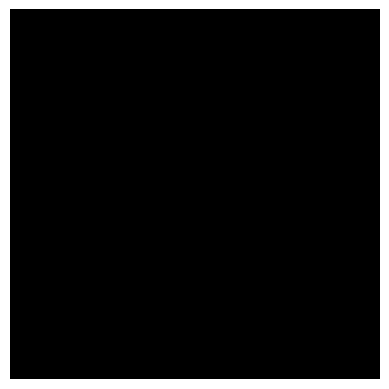

Threshold value: 50


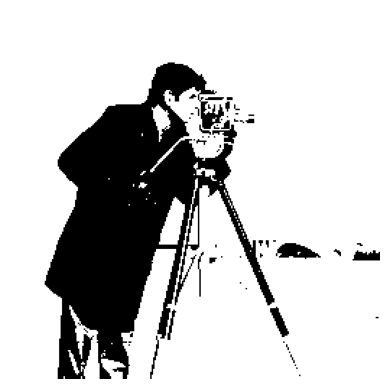

Threshold value: 100


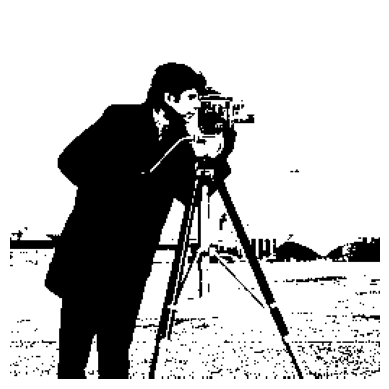

Threshold value: 150


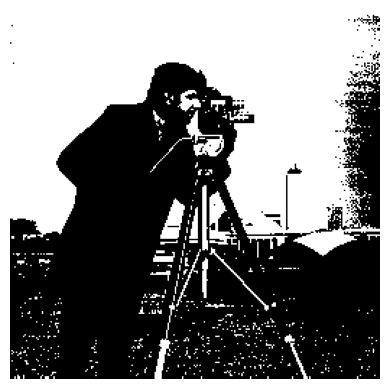

Threshold value: 200


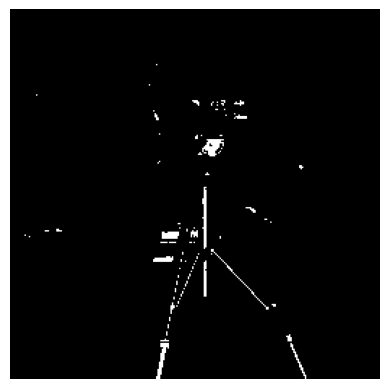

In [1]:
import cv2
import matplotlib.pyplot as plt

# Load the image in grayscale
img = cv2.imread('cameraman.png', cv2.IMREAD_GRAYSCALE)

# Set the threshold values
threshold_values = [0, 50, 100, 150, 200]

# Apply thresholding with different threshold values
for threshold_value in threshold_values:
    ret_thresh_value, thresh_img = cv2.threshold(img, threshold_value, 255, cv2.THRESH_BINARY)

    print(f"Threshold value: {threshold_value}")
    plt.imshow(thresh_img, cmap='gray')
    plt.axis('off')
    plt.show()

Original Image: 


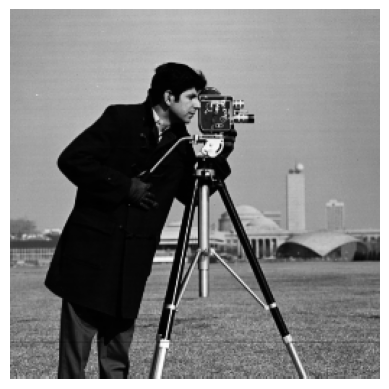

In [2]:
print("Original Image: ")
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.show()

## Histograms

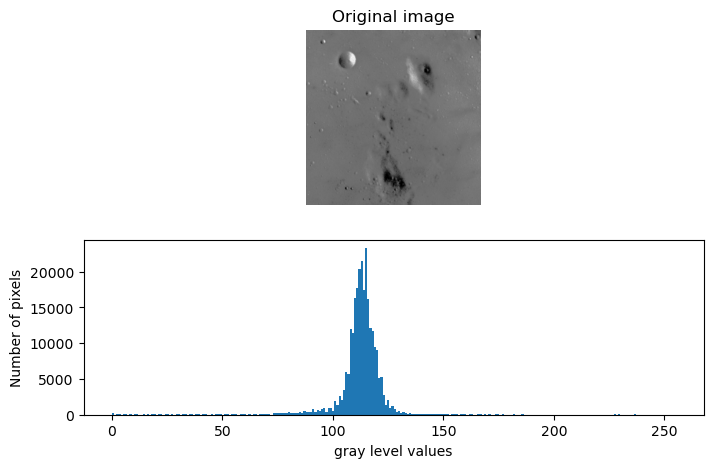

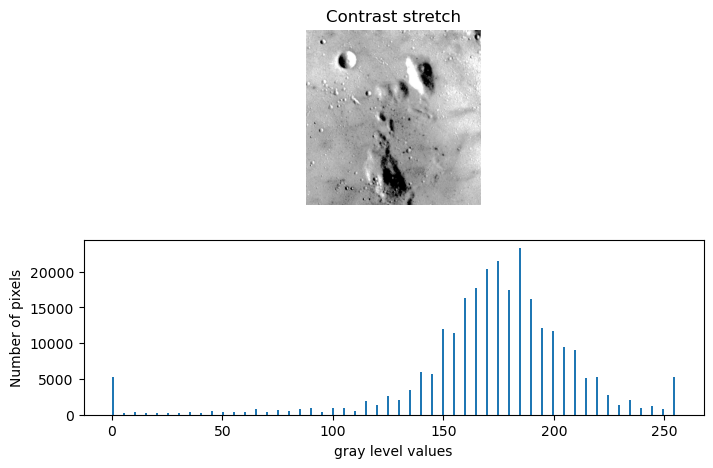

In [3]:
# Task#2: Histogram Processing

# Step#1: Load necessary libraries
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

from skimage import data
from skimage import exposure

# Step#2: Load moon image
img = data.moon()

# Step#3: Rescale intensity values to include all the intensities that fall within the 2nd and 98th percentiles
# Contrast stretching
p2, p98 = np.percentile(img, (2, 98))
img_rescale = exposure.rescale_intensity(img, in_range=(p2, p98))

# Step#4: Display the image with its histogram of (step#2)  and (step#3)
fig = plt.figure(figsize=(8, 5))
fig.add_subplot(2, 1, 1)
plt.imshow(img, cmap = 'gray')
plt.axis('off')
plt.title('Original image')

fig.add_subplot(2, 1, 2)
plt.hist(img.flat, bins = 256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

fig = plt.figure(figsize=(8, 5))
fig.add_subplot(2, 1, 1)
plt.imshow(img_rescale, cmap = 'gray')
plt.axis('off')
plt.title('Contrast stretch')

fig.add_subplot(2, 1, 2)
plt.hist(img_rescale.flat, bins = 256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

# Tasks:

Task1: Using the same ‘moon image’ Rescale intensity values to include all the intensities that fall within the 3nd and 80th percentiles, and plot the histogram

Task2: Using the same ‘moon image’ and the exposure.equalize_hist function, display the image and the histogram of the image after flattening the histogram.

Task3: Use the rocket (as reference) and chelsea images (from skimage.data) and implement histogram matching


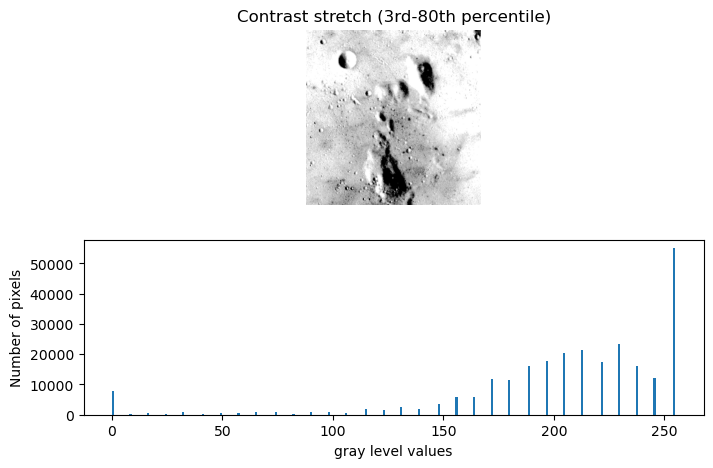

In [4]:
p3, p80 = np.percentile(img, (3, 80))
img_rescale_task1 = exposure.rescale_intensity(img, in_range=(p3, p80))

fig = plt.figure(figsize=(8, 5))
fig.add_subplot(2, 1, 1)
plt.imshow(img_rescale_task1, cmap='gray')
plt.axis('off')
plt.title('Contrast stretch (3rd-80th percentile)')

fig.add_subplot(2, 1, 2)
plt.hist(img_rescale_task1.flat, bins=256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

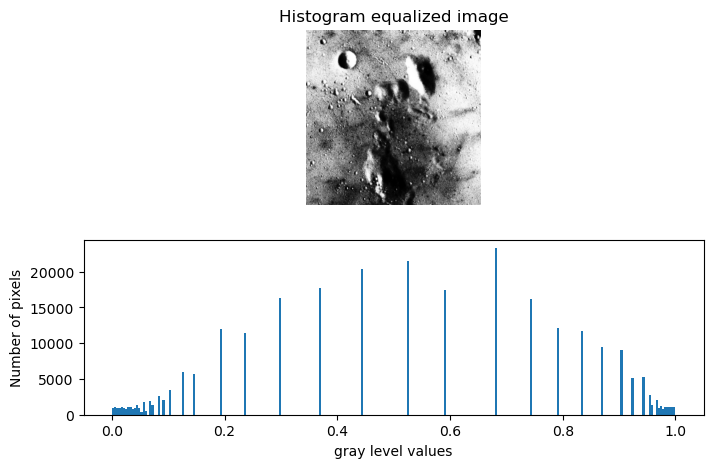

In [5]:
img_eq = exposure.equalize_hist(img)

fig = plt.figure(figsize=(8, 5))
fig.add_subplot(2, 1, 1)
plt.imshow(img_eq, cmap='gray')
plt.axis('off')
plt.title('Histogram equalized image')

fig.add_subplot(2, 1, 2)
# equalize_hist returns float values in [0, 1]
plt.hist(img_eq.flat, bins=256, range=(0, 1))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

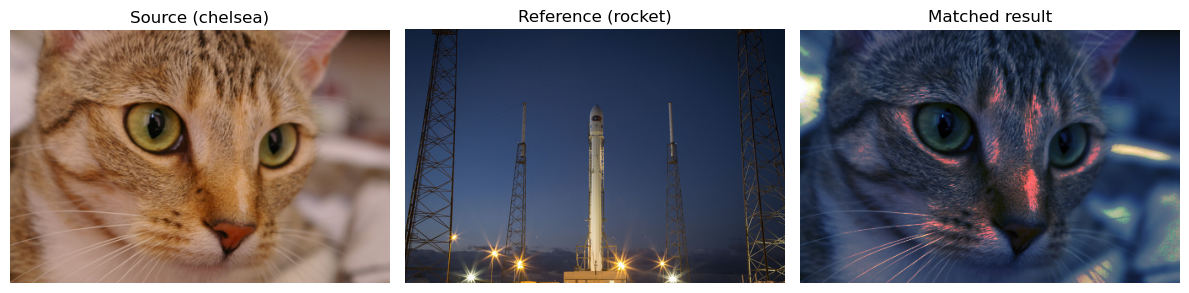

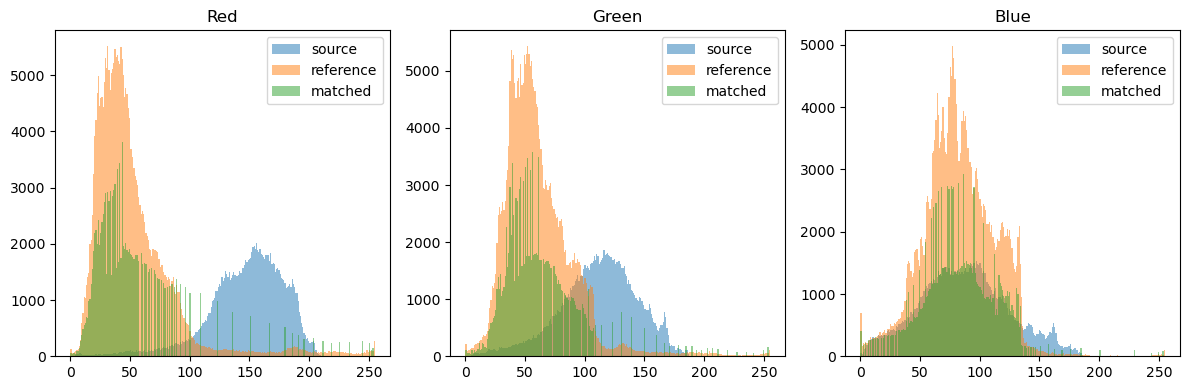

In [6]:
from skimage.exposure import match_histograms

reference = data.rocket()
image = data.chelsea()

# channel_axis=-1 because both images are color (RGB)
matched = match_histograms(image, reference, channel_axis=-1)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(image)
axes[0].set_title('Source (chelsea)')
axes[0].axis('off')

axes[1].imshow(reference)
axes[1].set_title('Reference (rocket)')
axes[1].axis('off')

axes[2].imshow(matched.astype('uint8'))
axes[2].set_title('Matched result')
axes[2].axis('off')

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharex=True)
for i, name in enumerate(['Red', 'Green', 'Blue']):
    axes[i].hist(image[..., i].ravel(), bins=256, range=(0, 255), alpha=0.5, label='source')
    axes[i].hist(reference[..., i].ravel(), bins=256, range=(0, 255), alpha=0.5, label='reference')
    axes[i].hist(matched[..., i].ravel(), bins=256, range=(0, 255), alpha=0.5, label='matched')
    axes[i].set_title(name)
    axes[i].legend()
plt.tight_layout()
plt.show()